# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [2]:
! pip install -q numpy
! pip install -q pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

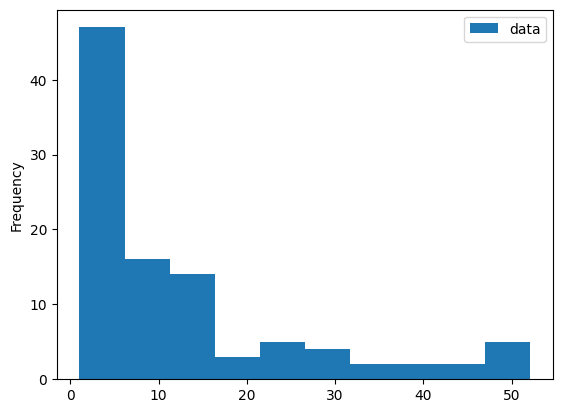

In [4]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

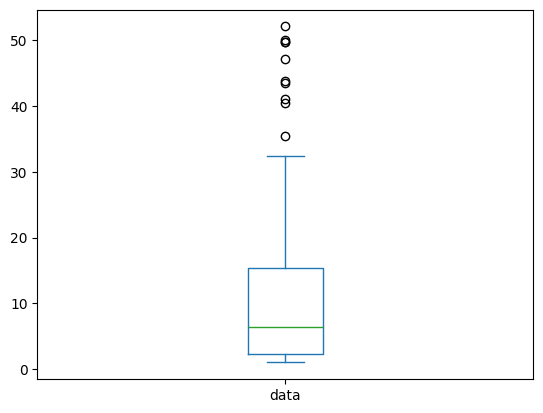

In [5]:
df.plot.box()

Histogram – Cons:
It is harder to read exact summary statistics such as the median or quartiles. The interpretation can also change depending on the number of bins chosen.

Boxplot – Pros:
The boxplot clearly shows the median, quartiles, spread, and outliers, which makes it very effective for understanding how expensive the high-price drugs are relative to the rest. The outliers (very high prices) are immediately visible.

Boxplot – Cons:
It hides the detailed shape of the distribution. We cannot see whether the lower prices are tightly clustered or spread out, and we lose the sense of frequency.

Which would I choose?

I would choose the boxplot for the administrator’s goal, because it directly shows how far the expensive drugs are from the typical price and highlights the outliers. That answers the business question more efficiently.

How I would improve the formatting

Add a descriptive title (e.g., “Distribution of Drug Prices in the Pharmacy”).

Label the x-axis with price in dollars.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [6]:
df= pd.read_csv ("state.csv", sep=',')
df.head()

,year,stabbr,state_name,statefip,region4,region9,effort,inc_effort,predicted_fedrevpp0_,predicted_fedrevpp10_,...,inc_gap130_ratio,coverage,state_chartershare,inc_pubsch,inc_nonpubsch,pubprv_incratio,case,citation,ruling,casetype
0,2022,AL,Alabama,1,South,East South Central,0.036929,0.039076,1108.649,1668.692,...,0.187758,0.825960,0.004447,94260.31,130562.7,0.721955,NaN,NaN,NaN,NaN
1,2022,AK,Alaska,2,West,Pacific,0.043423,0.056036,1776.774,3541.949,...,0.225224,0.821983,0.064936,109327.70,109224.8,1.000942,NaN,NaN,NaN,NaN
2,2022,AZ,Arizona,4,West,Mountain,0.024628,0.026759,1067.853,1859.725,...,0.190693,0.881690,0.351399,118109.90,137257.1,0.860501,NaN,NaN,NaN,NaN
3,2022,AR,Arkansas,5,South,West South Central,0.038394,0.037691,1381.248,2004.317,...,0.206366,0.859202,0.097590,90338.76,102996.4,0.877106,NaN,NaN,NaN,NaN
4,2022,CA,California,6,West,Pacific,0.030721,0.036699,1214.363,2042.963,...,0.155518,0.882351,0.153031,141409.50,225058.4,0.628324,NaN,NaN,NaN,NaN


In [7]:
num_df= df.select_dtypes(include='number')
num_df.shape
num_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1530.0,2007.500000,8.658271,1993.000000,2000.000000,2007.500000,2015.000000,2022.000000
statefip,1530.0,28.960784,15.681961,1.000000,16.000000,29.000000,42.000000,56.000000
effort,862.0,0.036511,0.006322,0.015759,0.031993,0.036168,0.040870,0.055217
inc_effort,1219.0,0.043408,0.007135,0.025232,0.038909,0.042800,0.047228,0.073341
predicted_fedrevpp0_,1469.0,413.420982,358.256173,53.021740,194.514800,322.614800,476.445200,4470.387000
...,...,...,...,...,...,...,...,...
coverage,1173.0,0.870169,0.034853,0.726157,0.850274,0.875658,0.893712,0.950709
state_chartershare,1122.0,0.043592,0.085533,0.000000,0.000951,0.020631,0.053254,0.766227
inc_pubsch,1173.0,84184.277587,24617.219172,39960.210000,66619.660000,79034.990000,97191.840000,202162.300000
inc_nonpubsch,1173.0,117335.307451,37960.625473,48956.750000,93201.330000,110297.500000,133216.700000,372437.900000


In [8]:
 #selected columns
Sel_col= num_df[['effort','coverage','count','enrolled','lowinc_ec','lowinc_enrolled','ec_enrollgapratio' ]]     

#effort → % of state economic capacity spent on K-12
# count → number of all 3–4 year olds
# enrolled → number of 3–4 year olds enrolled
# lowinc_ec → low-income 3–4 year olds
# lowinc_enrolled → low-income enrolled
# ec_enrollgapratio → equity measure (low-income enrollment rate ÷ overall rate)

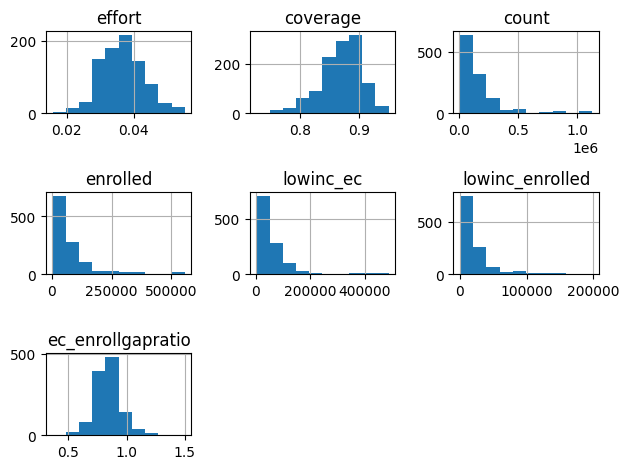

In [9]:
Sel_col.hist()
plt.tight_layout()

<Axes: >

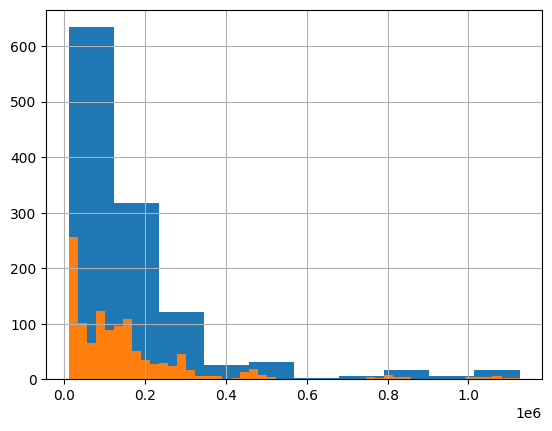

In [10]:
Sel_col['count'].hist(bins=10)
Sel_col['count'].hist(bins=50)

enrolled, income and count seem to be right skewed.


Increasing the number of bins reveals more detail in the distribution but does not change the overall right-skewed shape.

None of the population-based variables follow a normal distribution.

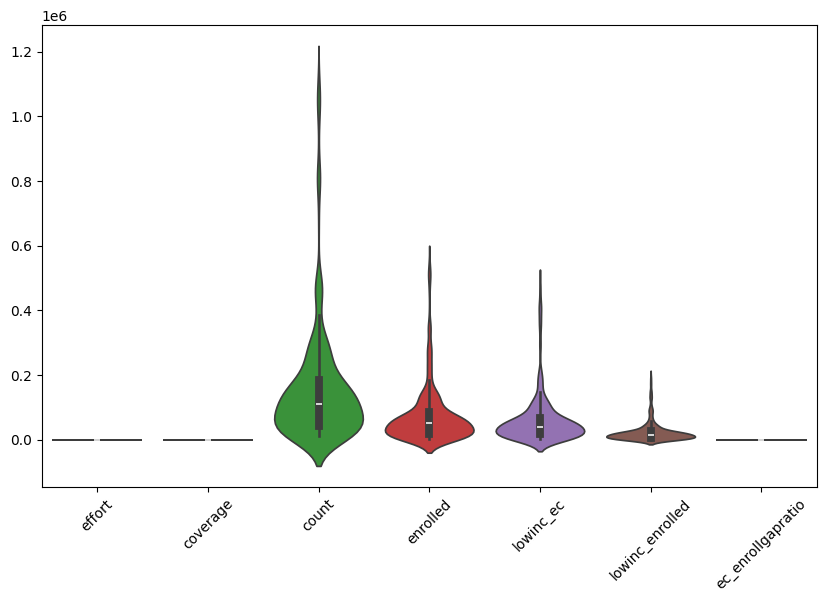

In [11]:
#Violin plot
plt.figure(figsize=(10,6))
sns.violinplot(data=Sel_col)
plt.xticks(rotation=45)
None

The violin plot shows that population-based variables are highly right-skewed, reflecting the large differences in state sizes. Variables expressed as percentages or ratios appear compressed because they are on a much smaller scale. This indicates that the dataset contains meaningful real-world variation and that future analysis should treat count and rate variables separately.

In [12]:
#lets make a small and a big set 
small = Sel_col[['effort','coverage','ec_enrollgapratio']]
large = Sel_col[['count','enrolled','lowinc_ec','lowinc_enrolled']]

<Axes: >

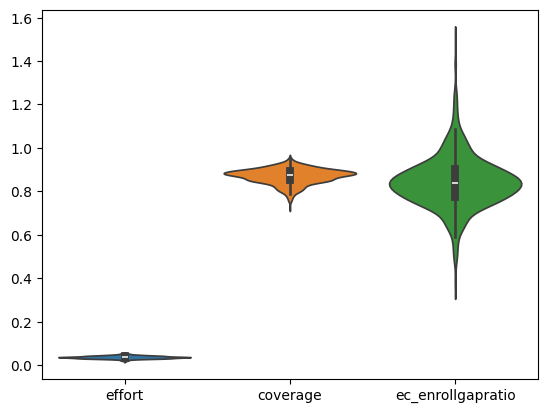

In [13]:
sns.violinplot(data= small)

<Axes: ylabel='effort'>

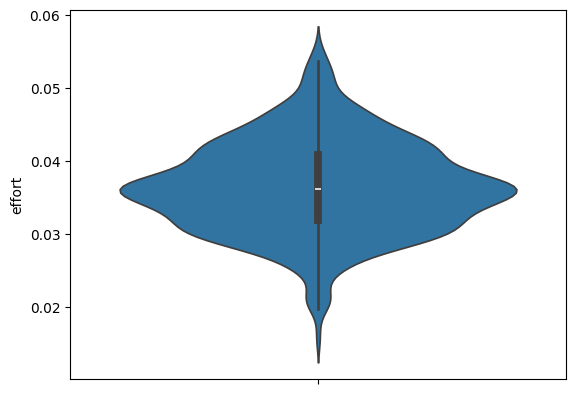

In [14]:
sns.violinplot(Sel_col['effort'])

/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 70.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 79.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 82.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 89.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: >

/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 74.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 82.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 84.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 91.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


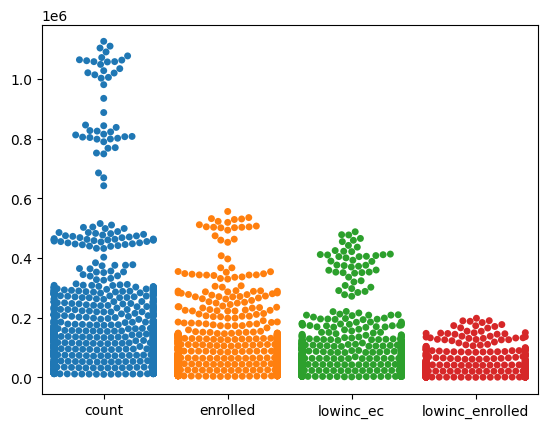

In [15]:
sns.swarmplot(data=large)


The swarm plot shows that all population-based variables are strongly right-skewed, with most states clustered at lower values and a few states having very large populations. This pattern is expected in demographic data and indicates that the dataset is realistic. A clear hierarchical structure is visible, where the total child population is larger than the number enrolled, which in turn is larger than the low-income population and low-income enrollment. This confirms the internal consistency of the dataset. Several extreme values appear, but these likely correspond to large states rather than data errors. Because these variables are population counts, future analysis should use enrollment rates rather than raw counts to allow meaningful comparisons across states.

<Axes: >

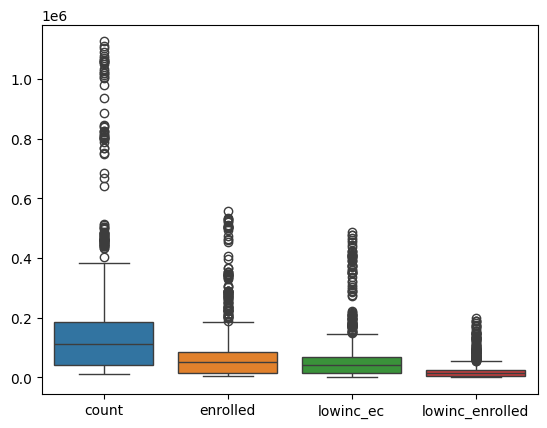

In [16]:
sns.boxplot(data=large)


<Axes: ylabel='effort'>

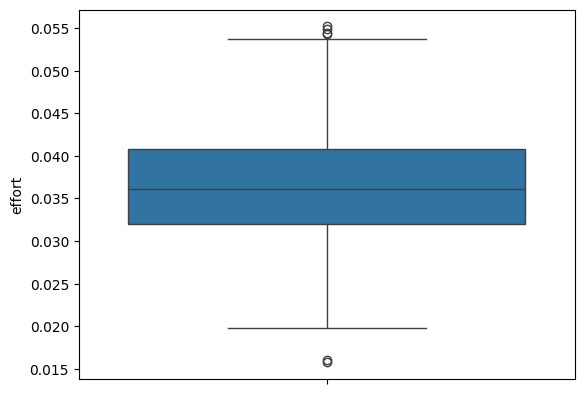

In [17]:
sns.boxplot(Sel_col['effort'])


The effort variable shows a relatively narrow distribution with a few high outliers, indicating that most states spend similar amounts per child while a small number invest substantially more. In contrast, enrollment and count variables are highly right-skewed, reflecting population size differences across states. This suggests the dataset is consistent with real-world expectations and suitable for further analysis.

In [18]:
#I'm curious to see which states has the highest effort
df.sort_values('effort', ascending=False)[['effort', 'state_name']].head(10)

,effort,state_name
657,0.055217,Vermont
708,0.054919,Vermont
356,0.054396,Wyoming
759,0.054286,Vermont
810,0.053777,Vermont
615,0.053019,Arkansas
453,0.052865,Vermont
305,0.052781,Wyoming
606,0.052739,Vermont
846,0.052242,New Jersey


# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

<BarContainer object of 5 artists>

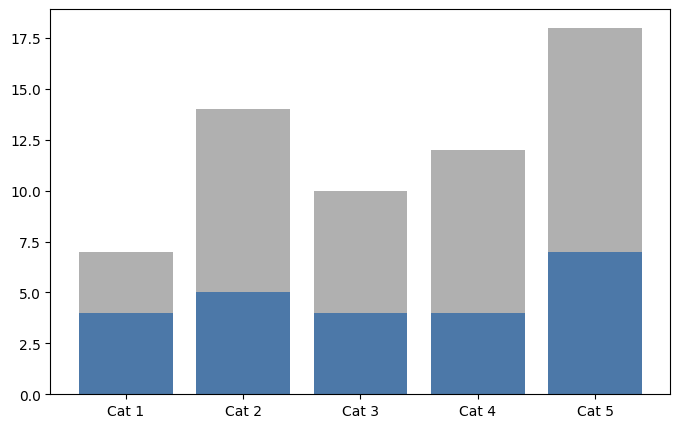

In [19]:

categories = ['Cat 1', 'Cat 2', 'Cat 3', 'Cat 4', 'Cat 5']

blue = np.array([4, 5, 4, 4, 7])     # bottom part
gray = np.array([3, 9, 6, 8, 11])    # top part

plt.figure(figsize=(8,5))

plt.bar(categories, blue, color='#4C78A8')                 # bottom
plt.bar(categories, gray, bottom=blue, color='#B0B0B0')    # stacked on top

